<a href="https://colab.research.google.com/github/zakyboss/170421-3F-AI-Policy-iteration-and-Value-iteration-Assignment/blob/main/updated_policy_iteration_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importing required libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Opening recorded data

In [ ]:
policy_iteration_data = pd.read_csv("/content/policy_iteration.csv")

In [ ]:
policy_iteration_data.head()

,"(0,0)","(1,0)","(2,0)","(3,0)","(4,0)","(5,0)","(6,0)","(7,0)","(8,0)","(9,0)",...,"(8,17)","(9,17)","(10,17)","(11,17)","(12,17)","(13,17)","(14,17)","(15,17)","(16,17)","(17,17)"
0,0.000000,0.000000,0,0,0,0.000000,0.000000,0.000000,0.000000,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0
1,-0.040000,-0.040000,0,0,0,1.000000,-0.040000,-0.040000,-0.040000,0,...,-1.000000,-1.000000,-0.040000,-0.040000,-1.000000,1.000000,-0.040000,1.000000,-1.000000,0
2,0.023360,0.023360,0,0,0,1.063360,-0.174640,-0.174640,-0.079600,0,...,-1.894960,-1.134640,-0.174640,-0.839920,-0.406000,1.063360,0.744080,0.303040,-1.894960,0
3,0.167631,0.075893,0,0,0,0.893999,-0.363603,-0.223253,-0.118804,0,...,-2.103525,-1.343205,-0.910107,-0.527856,-0.238207,1.696897,0.275984,-0.468495,-2.705699,0
4,0.221657,0.120838,0,0,0,0.666716,-0.426556,-0.265791,-0.157616,0,...,-2.369620,-2.026606,-0.816027,-0.333175,0.296777,1.402159,-0.369148,-1.204758,-3.454226,0


In [ ]:
policy_iteration_data.tail()

,"(0,0)","(1,0)","(2,0)","(3,0)","(4,0)","(5,0)","(6,0)","(7,0)","(8,0)","(9,0)",...,"(8,17)","(9,17)","(10,17)","(11,17)","(12,17)","(13,17)","(14,17)","(15,17)","(16,17)","(17,17)"
1296,91.797936,91.644030,0,0,0,89.141953,88.042799,89.132961,90.278082,0,...,86.249872,87.757108,90.255086,91.757430,92.966496,95.402950,94.433758,94.496874,92.198278,0
1297,91.797942,91.644035,0,0,0,89.141960,88.042806,89.132969,90.278090,0,...,86.249886,87.757114,90.255092,91.757436,92.966502,95.402956,94.433764,94.496880,92.198284,0
1298,91.797948,91.644041,0,0,0,89.141966,88.042813,89.132977,90.278097,0,...,86.249900,87.757120,90.255098,91.757442,92.966508,95.402962,94.433770,94.496886,92.198290,0
1299,91.797953,91.644047,0,0,0,89.141973,88.042820,89.132985,90.278105,0,...,86.249914,87.757126,90.255104,91.757448,92.966514,95.402968,94.433776,94.496892,92.198296,0
1300,91.797959,91.644052,0,0,0,89.141980,88.042827,89.132992,90.278113,0,...,86.249928,87.757132,90.255110,91.757454,92.966520,95.402974,94.433782,94.496897,92.198302,0


### Plotting relevant data

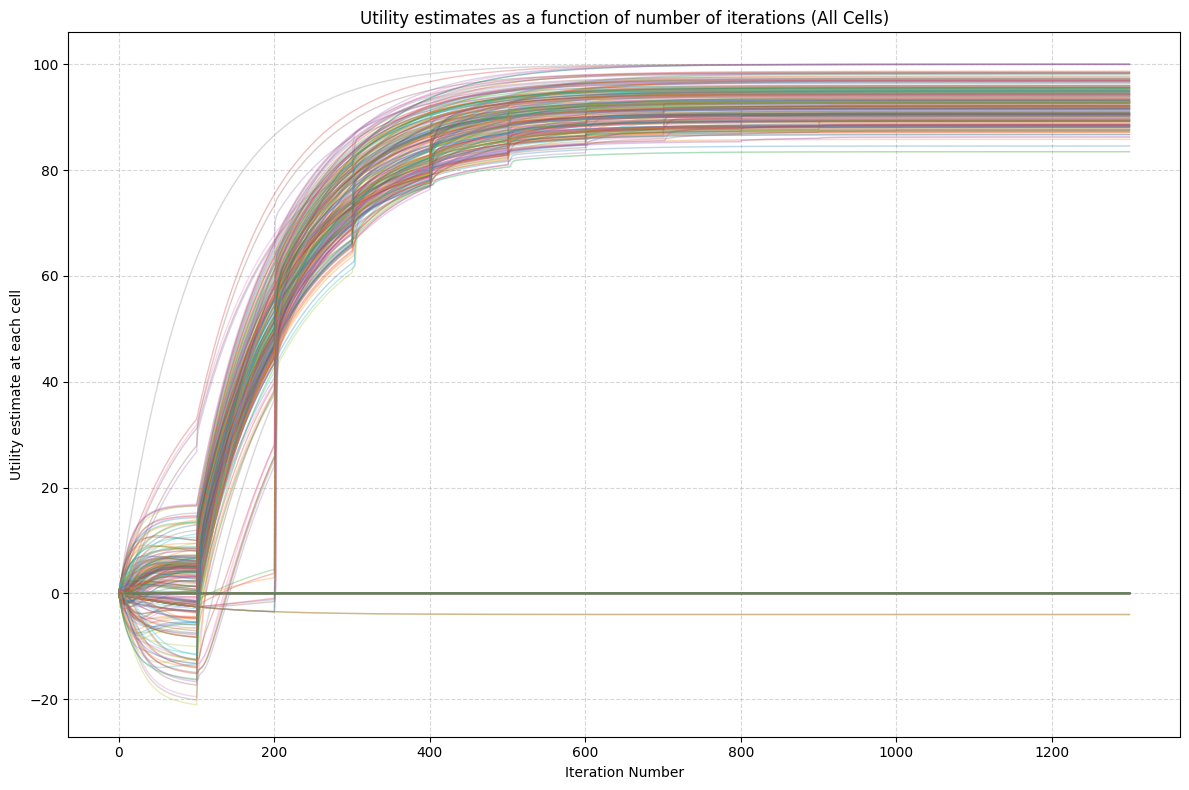

In [ ]:
plt.figure(figsize=(12, 8))

# Passing the entire DataFrame plots all columns in a single vectorized step
plt.plot(policy_iteration_data, alpha=0.3, linewidth=1)


# Labels & styling
plt.title("Utility estimates as a function of number of iterations (All Cells)")
plt.xlabel("Iteration Number")
plt.ylabel("Utility estimate at each cell")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

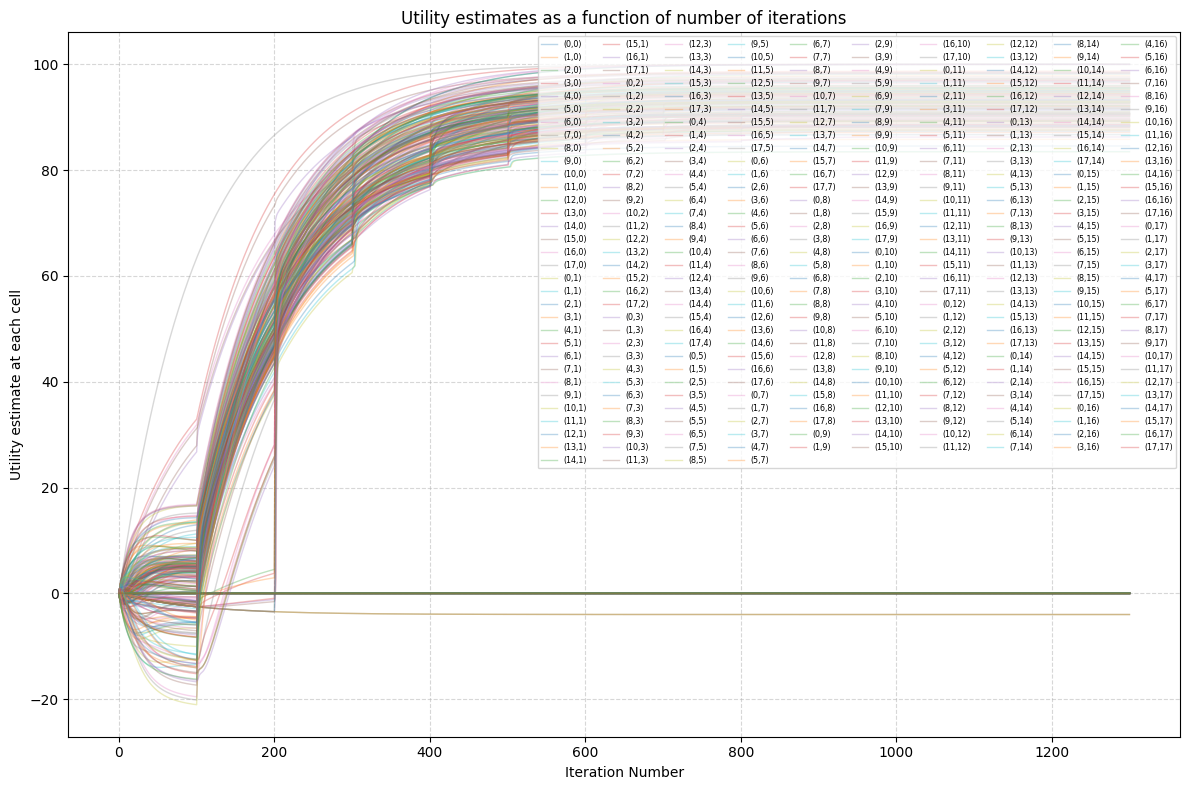

In [ ]:
plt.figure(figsize=(12, 8))

for column in policy_iteration_data.columns:
  plt.plot(policy_iteration_data[column], label=column, alpha=0.3, linewidth=1)

plt.title("Utility estimates as a function of number of iterations")
plt.xlabel("Iteration Number")
plt.ylabel("Utility estimate at each cell")
plt.grid(True, linestyle="--", alpha=0.5)

# Full legend placed at the top right
plt.legend(loc="upper right", fontsize="xx-small", ncol=10)

plt.tight_layout()
plt.show()

---
## Extending the analysis: parameter experiments

The cells above analyze one already-recorded run (`policy_iteration.csv`). The cells
below run Policy Iteration (and Value Iteration, for the final comparison) under
several different settings so they can all be compared together. Before running
these cells, upload `environment.py`, `constants.py`, `complex_constants.py`, and the
`algorithms/` folder (containing `policy_iteration.py` and `value_iteration.py`) into
this Colab session's file browser, matching the same structure `main.py` expects.


In [ ]:
import os
os.environ["SDL_VIDEODRIVER"] = "dummy"  # constants.py loads a pygame font at import time; this avoids needing a real display
os.environ["SDL_AUDIODRIVER"] = "dummy"

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from environment import Environment
from algorithms.policy_iteration import PolicyIteration
from algorithms.value_iteration import ValueIteration


In [ ]:
import constants
import complex_constants

small_grid, small_h, small_w = constants.grid, constants.grid_height, constants.grid_width
actions = constants.actions
small_rewards = constants.rewards

big_grid, big_h, big_w = complex_constants.grid, complex_constants.grid_height, complex_constants.grid_width
big_rewards = complex_constants.rewards

small_mdp = Environment(small_grid, small_h, small_w, actions, small_rewards)
big_mdp = Environment(big_grid, big_h, big_w, actions, big_rewards)


pygame 2.6.1 (SDL 2.28.4, Python 3.12.3)
Hello from the pygame community. https://www.pygame.org/contribute.html


### All experiments together: policy eval iterations (k) and grid size

In [ ]:
baseline_gamma, baseline_k = 0.99, 100

pi_experiments = []
k_policies = {}

for k in [1, 5, 20, 100, 500]:
    t0 = time.time()
    res = PolicyIteration(baseline_gamma, k).solve_mdp(small_mdp)
    pi_experiments.append({"Experiment": "Policy eval iters (k)", "Setting": f"k={k}",
                            "Iterations": res["num_iters"], "Time (s)": round(time.time()-t0, 4)})
    k_policies[k] = res["optimal_policy"]

t0 = time.time()
res_small = PolicyIteration(baseline_gamma, baseline_k).solve_mdp(small_mdp)
pi_experiments.append({"Experiment": "Grid size", "Setting": "6x6 (small)",
                        "Iterations": res_small["num_iters"], "Time (s)": round(time.time()-t0, 4)})

t0 = time.time()
res_big = PolicyIteration(baseline_gamma, baseline_k).solve_mdp(big_mdp)
pi_experiments.append({"Experiment": "Grid size", "Setting": "18x18 (complex)",
                        "Iterations": res_big["num_iters"], "Time (s)": round(time.time()-t0, 4)})

pi_experiments_df = pd.DataFrame(pi_experiments)
pi_experiments_df


,Experiment,Setting,Iterations,Time (s)
0,Policy eval iters (k),k=1,7,0.0025
1,Policy eval iters (k),k=5,45,0.0072
2,Policy eval iters (k),k=20,140,0.0136
3,Policy eval iters (k),k=100,700,0.0681
4,Policy eval iters (k),k=500,3500,0.3354
5,Grid size,6x6 (small),700,0.0635
6,Grid size,18x18 (complex),1000,0.8222


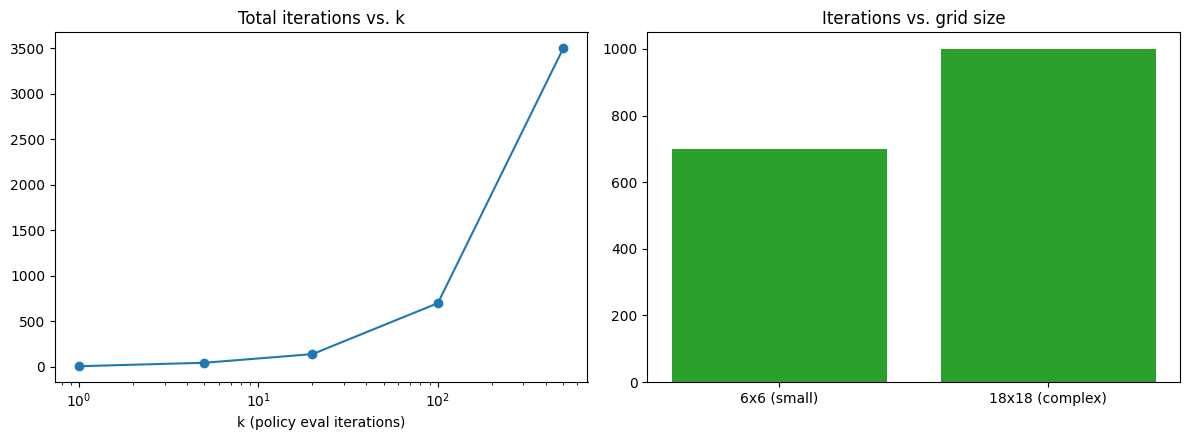

Does every k converge to the SAME final policy as k=500?
  k=   1: False
  k=   5: False
  k=  20: True
  k= 100: True
  k= 500: True

Saved to policy_iteration_experiments_summary.csv


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

k_rows = pi_experiments_df[pi_experiments_df["Experiment"] == "Policy eval iters (k)"]
axes[0].plot(k_rows["Setting"].str.replace("k=", "").astype(int), k_rows["Iterations"], marker="o")
axes[0].set_xscale("log")
axes[0].set_title("Total iterations vs. k")
axes[0].set_xlabel("k (policy eval iterations)")

grid_rows = pi_experiments_df[pi_experiments_df["Experiment"] == "Grid size"]
axes[1].bar(grid_rows["Setting"], grid_rows["Iterations"], color="tab:green")
axes[1].set_title("Iterations vs. grid size")

plt.tight_layout()
plt.show()

print("Does every k converge to the SAME final policy as k=500?")
for k in [1, 5, 20, 100, 500]:
    print(f"  k={k:>4}: {k_policies[k] == k_policies[500]}")

pi_experiments_df.to_csv("policy_iteration_experiments_summary.csv", index=False)
print("\nSaved to policy_iteration_experiments_summary.csv")


---
## Cross-algorithm comparison: Value Iteration vs. Policy Iteration

Both algorithms, both grid sizes, run head-to-head with their default/baseline settings.


In [ ]:
cross_results = []
for name, mdp, label in [("VI", small_mdp, "6x6"), ("VI", big_mdp, "18x18"),
                          ("PI", small_mdp, "6x6"), ("PI", big_mdp, "18x18")]:
    t0 = time.time()
    if name == "VI":
        res = ValueIteration(0.99).solve_mdp(mdp, 0.05)
    else:
        res = PolicyIteration(0.99, 100).solve_mdp(mdp)
    cross_results.append({"Algorithm": name, "Grid": label,
                           "Iterations": res["num_iters"], "Time (s)": round(time.time()-t0, 4)})

cross_df = pd.DataFrame(cross_results)
cross_df


,Algorithm,Grid,Iterations,Time (s)
0,VI,6x6,757,0.2081
1,VI,18x18,757,1.5228
2,PI,6x6,700,0.0701
3,PI,18x18,1000,0.6922


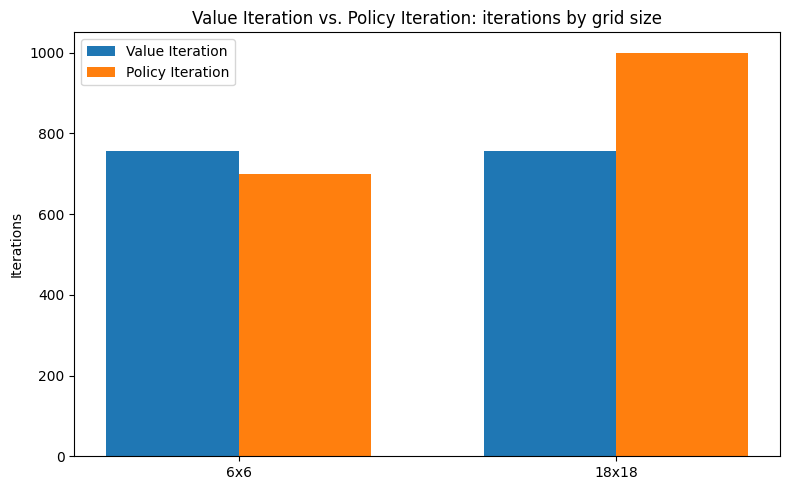

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
width = 0.35
grids = ["6x6", "18x18"]
vi_vals = [cross_df[(cross_df.Algorithm=="VI") & (cross_df.Grid==g)]["Iterations"].values[0] for g in grids]
pi_vals = [cross_df[(cross_df.Algorithm=="PI") & (cross_df.Grid==g)]["Iterations"].values[0] for g in grids]
x = np.arange(len(grids))
ax.bar(x - width/2, vi_vals, width, label="Value Iteration")
ax.bar(x + width/2, pi_vals, width, label="Policy Iteration")
ax.set_xticks(x)
ax.set_xticklabels(grids)
ax.set_ylabel("Iterations")
ax.set_title("Value Iteration vs. Policy Iteration: iterations by grid size")
ax.legend()
plt.tight_layout()
plt.show()


### Observations

- **Policy eval iterations (k):** When k is too small, the algorithm doesn't evaluate a policy properly before deciding how to improve it similar to judging a plan before it has had time to play out. This can lead the algorithm to settle on the wrong final policy, not just take longer to find the right one.
- **Grid size:** Unlike Value Iteration, Policy Iteration's iteration count increased when the grid got bigger. This fits with the earlier finding: Value Iteration's speed depends mainly on γ, while Policy Iteration has more work to do simply because there are more cells to evaluate and improve each round.
- **Cross-algorithm:** Policy Iteration needed fewer iterations than Value Iteration on the small grid, but more on the big grid. This means neither algorithm is simply "better" overall which one wins depends on the size of the problem.
